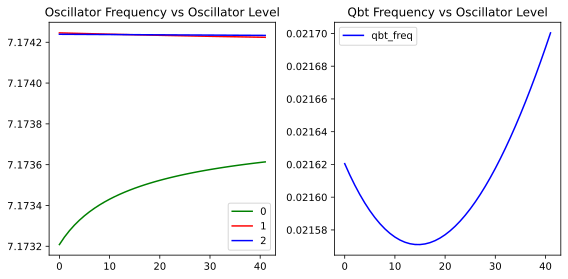

In [9]:

import sys
sys.path.append('../')
from utils_models import *

def plot_frequencies_qbt_osc(dressed_ener: Callable, ols):
    colors = ['green', 'red', 'blue', 'orange']

    # Create a figure and a set of subplots
    fig, axs = plt.subplots(1, 2, figsize=(8, 4))  # Adjusted for better spacing

    # Second subplot for oscillator frequencies
    for ql in [0, 1, 2]:
        osc_energies = []
        for ol in range(0, ols - 8):
            osc_energies.append(dressed_ener(ql, ol + 1) - dressed_ener(ql, ol))
        axs[0].plot(list(range(ols - 8)), osc_energies, label=f'{ql}', color=colors[ql])
    axs[0].set_title('Oscillator Frequency vs Oscillator Level')
    axs[0].legend()



    qbt_energies = []
    for ol in range(ols-8):
        qbt_energies.append(dressed_ener(2, ol) - dressed_ener(1, ol))
    axs[1].plot(list(range(ols-8)), qbt_energies, label=f'qbt_freq', color=colors[ql])
    axs[1].set_title('Qbt Frequency vs Oscillator Level')
    axs[1].legend()

    # Show the plots
    plt.tight_layout()  # Adjust the layout to make room for the legend
    plt.show()
    
max_ql = 12
max_ol = 50
system = FluxoniumOscillatorSystem(
    computaional_states = '1,2',
    EJ = 2.65,
    EC = 0.6,
    EL = 0.13,
    Er = 7.17391479,
    g_strength = 0.12,
    qubit_level = max_ql,
    osc_level = max_ol,
    products_to_keep=[[ql, ol] for ql in [1,2] for ol in range(30) ],
)

energies=  system.hilbertspace.eigenvals(system.qbt.truncated_dim * system.osc.truncated_dim )


def dressed_ener(ql,ol):
    return energies[system.product_to_dressed[(ql,ol)]]


ols = system.osc.truncated_dim

plot_frequencies_qbt_osc(dressed_ener, ols)

In [2]:
freqs = np.linspace(7.1714,7.1754,100)
freqs

array([7.1714    , 7.1714404 , 7.17148081, 7.17152121, 7.17156162,
       7.17160202, 7.17164242, 7.17168283, 7.17172323, 7.17176364,
       7.17180404, 7.17184444, 7.17188485, 7.17192525, 7.17196566,
       7.17200606, 7.17204646, 7.17208687, 7.17212727, 7.17216768,
       7.17220808, 7.17224848, 7.17228889, 7.17232929, 7.1723697 ,
       7.1724101 , 7.17245051, 7.17249091, 7.17253131, 7.17257172,
       7.17261212, 7.17265253, 7.17269293, 7.17273333, 7.17277374,
       7.17281414, 7.17285455, 7.17289495, 7.17293535, 7.17297576,
       7.17301616, 7.17305657, 7.17309697, 7.17313737, 7.17317778,
       7.17321818, 7.17325859, 7.17329899, 7.17333939, 7.1733798 ,
       7.1734202 , 7.17346061, 7.17350101, 7.17354141, 7.17358182,
       7.17362222, 7.17366263, 7.17370303, 7.17374343, 7.17378384,
       7.17382424, 7.17386465, 7.17390505, 7.17394545, 7.17398586,
       7.17402626, 7.17406667, 7.17410707, 7.17414747, 7.17418788,
       7.17422828, 7.17426869, 7.17430909, 7.17434949, 7.17438

In [5]:
def get_matrix_element(ql):
    operator = system.hilbertspace.op_in_dressed_eigenbasis(system.osc.n_operator)
    element = operator[system.product_to_dressed[(ql,1)],system.product_to_dressed[(ql,0)]]
    return np.abs(element) 
g0g1 = get_matrix_element(0)
e0e1 = get_matrix_element(1)
f0f1 = get_matrix_element(2)
h0h1 = get_matrix_element(3)
max_element = max([g0g1, e0e1, f0f1, h0h1])
g0g1, e0e1, f0f1, h0h1, max_element

(0.6950333706466276,
 0.7067746364724473,
 0.7070110211388515,
 0.7070718545703604,
 0.7070718545703604)

In [6]:
t_stop = 0.5 / 0.002/ max_element
t_stop

353.57085476398726

In [8]:
import sys
sys.path.append('../')
from utils_models import *


max_ql = 12
max_ol = 20
t_stop = 360

tlist = np.linspace(0,t_stop,t_stop)


In [10]:

with open(f'../pickles/12_response.pkl', 'rb') as file:
    results = pickle.load(file)

In [11]:
pn_exp = [[] for _ in [0,1,2]]
result_counter = 0
for initial_i in [0,1,2]:
    for freq in freqs:
        pn_exp[initial_i].append(np.max(results[result_counter].expect[0]))
        result_counter += 1

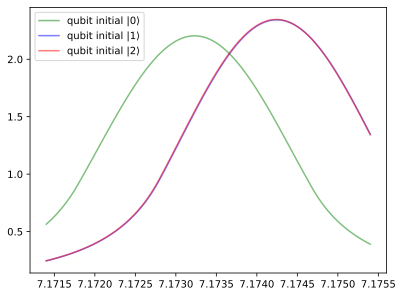

In [12]:
colors = ['green','blue','red','darkorange']
for i in [0,1,2]:
    plt.plot(freqs,pn_exp[i],color = colors[i],alpha = 0.5,label = rf'qubit initial $ | {i} \rangle$')
plt.legend()
# plt.xlim(7.1600,7.171)